# Notebook debug pipeline Weakly Supervised Bone Segmentation

Notebook này dùng để quan sát từng bước của pipeline, không dùng làm notebook benchmark hay training hàng loạt.

Bạn nên chạy từ trên xuống, dừng sau từng cell, nhìn hình và đọc bảng metric trước khi chạy tiếp.

Luồng chính của một ảnh:

```text
Ảnh X-quang đầu vào
  -> preprocessing
  -> classifier DenseNet121
  -> LayerCAM
  -> threshold CAM
  -> morphology theo cường độ và cạnh xương
  -> connected components
  -> prompt bbox/point
  -> SAM
  -> chọn pseudo mask
  -> hậu xử lý morphology
  -> evaluation với ground truth
```

Nguyên tắc của notebook: tham số của stage nào nằm ngay trước stage đó. Khi muốn thử tham số khác, bạn sửa tại đúng vị trí đang đọc, không cần quay lên đầu notebook.

## 1. Thiết lập nền tảng

Cell này chỉ làm các việc nền tảng:

- import thư viện thường dùng;
- khai báo `WORKSPACE_ROOT` và `PROJECT_DIR`;
- đưa `PROJECT_DIR` vào `sys.path`;
- tạo thư mục lưu kết quả debug.

Cell này không chứa toàn bộ tham số pipeline. Tham số của preprocessing, CAM, morphology, SAM và evaluation sẽ được đặt ngay trước stage tương ứng.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path
import sys
import json
import subprocess
import warnings

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

# WORKSPACE_ROOT là thư mục gốc của project trên máy hiện tại.
WORKSPACE_ROOT = Path(r'/content/drive/MyDrive/Thesis Experiment')

# PROJECT_DIR chứa các module Python của project.
PROJECT_DIR = WORKSPACE_ROOT / 'repo' / 'project'

# OUTPUT_ROOT chỉ dùng cho kết quả debug của notebook này.
OUTPUT_ROOT = WORKSPACE_ROOT / 'debug_outputs'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print('WORKSPACE_ROOT:', WORKSPACE_ROOT)
print('PROJECT_DIR   :', PROJECT_DIR)
print('OUTPUT_ROOT   :', OUTPUT_ROOT)
print('PROJECT_DIR tồn tại:', PROJECT_DIR.exists())

WORKSPACE_ROOT: /content/drive/MyDrive/Thesis Experiment
PROJECT_DIR   : /content/drive/MyDrive/Thesis Experiment/repo/project
OUTPUT_ROOT   : /content/drive/MyDrive/Thesis Experiment/debug_outputs
PROJECT_DIR tồn tại: True


## 2. Kiểm tra môi trường và mã nguồn

Mục đích: biết notebook đang chạy với Python/PyTorch nào, có GPU hay không, và các file nguồn cần thiết có tồn tại không.

Nếu thiếu thư viện, bật `RUN_INSTALL_DEPS=True` trong cell này. Các gói được cài:

- `pycocotools`: đọc annotation COCO RLE của RAM-H1200.
- `opencv-python`: dùng CLAHE và Sobel cho morphology.
- `segment-anything`: dùng SAM ViT-B.

Khi debug trên máy đã cài đủ thư viện, nên để `RUN_INSTALL_DEPS=False` để cell chạy nhanh.

In [3]:
import torch

# Chỉ bật khi môi trường thiếu thư viện. Bật lên sẽ chạy pip install và mất thời gian.
RUN_INSTALL_DEPS = True

print('Python:', sys.version)
print('PyTorch:', torch.__version__)
print('CUDA khả dụng:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

if RUN_INSTALL_DEPS:
    for package_args in [
        ['pycocotools'],
        ['opencv-python'],
        ['--no-deps', 'git+https://github.com/facebookresearch/segment-anything.git'],
    ]:
        print('Đang cài:', ' '.join(package_args))
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *package_args], check=True)
else:
    print('Không cài thêm thư viện vì RUN_INSTALL_DEPS=False.')

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch: 2.11.0+cu128
CUDA khả dụng: True
GPU: Tesla T4
Đang cài: pycocotools
Đang cài: opencv-python
Đang cài: --no-deps git+https://github.com/facebookresearch/segment-anything.git


In [4]:
required_files = [
    PROJECT_DIR / 'datasets' / 'ramh1200.py',
    PROJECT_DIR / 'datasets' / 'common.py',
    PROJECT_DIR / 'models' / 'classifier.py',
    PROJECT_DIR / 'models' / 'layercam.py',
    PROJECT_DIR / 'pseudo' / 'bone_morphology.py',
    PROJECT_DIR / 'pseudo' / 'mask_selection.py',
    PROJECT_DIR / 'pseudo' / 'morphology.py',
    PROJECT_DIR / 'pseudo' / 'sam_refine.py',
    PROJECT_DIR / 'generate_pseudo_masks.py',
    PROJECT_DIR / 'evaluate_ramh1200_masks.py',
    PROJECT_DIR / 'train_classifier.py',
    PROJECT_DIR / 'train_segmentation.py',
]
for path in required_files:
    print(('OK   ' if path.exists() else 'THIẾU'), path)

OK    /content/drive/MyDrive/Thesis Experiment/repo/project/datasets/ramh1200.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/datasets/common.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/models/classifier.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/models/layercam.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/pseudo/bone_morphology.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/pseudo/mask_selection.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/pseudo/morphology.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/pseudo/sam_refine.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/generate_pseudo_masks.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/evaluate_ramh1200_masks.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/train_classifier.py
OK    /content/drive/MyDrive/Thesis Experiment/repo/project/train_segmentation.py


## 3. Helper visualize và metric

Các helper này chỉ phục vụ hiển thị trong notebook. Chúng không thay đổi thuật toán của project.

Các hàm chính:

- `show_image`: hiển thị một ảnh.
- `show_row`: hiển thị nhiều ảnh trên cùng một hàng.
- `overlay_mask`: phủ mask nhị phân lên ảnh gốc.
- `overlay_cam`: phủ heatmap CAM lên ảnh gốc.
- `plot_histogram`: xem phân bố giá trị của ảnh/CAM/mask.
- `binary_metrics_np`: tính Dice, IoU, precision, recall và foreground ratio.
- `visualize_connected_components`: tô màu các component để kiểm tra vùng nào được giữ lại.

In [5]:
def show_image(title, image, cmap=None, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_row(items, figsize=(16, 4)):
    fig, axes = plt.subplots(1, len(items), figsize=figsize)
    if len(items) == 1:
        axes = [axes]
    for ax, (title, image, cmap) in zip(axes, items):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def overlay_mask(image_rgb, mask_bool, color=(255, 40, 40), alpha=0.45):
    image = image_rgb.copy().astype(np.float32)
    color = np.asarray(color, dtype=np.float32)
    mask_bool = mask_bool.astype(bool)
    image[mask_bool] = (1 - alpha) * image[mask_bool] + alpha * color
    return np.clip(image, 0, 255).astype(np.uint8)


def overlay_cam(image_rgb, cam, alpha=0.45):
    cam = np.asarray(cam, dtype=np.float32)
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cmap = plt.get_cmap('jet')
    heat = (cmap(cam)[..., :3] * 255).astype(np.uint8)
    return np.clip((1 - alpha) * image_rgb + alpha * heat, 0, 255).astype(np.uint8)


def plot_histogram(values, title, bins=50):
    values = np.asarray(values).ravel()
    plt.figure(figsize=(6, 3))
    plt.hist(values, bins=bins)
    plt.title(title)
    plt.xlabel('Giá trị')
    plt.ylabel('Số pixel')
    plt.grid(alpha=0.25)
    plt.show()


def binary_metrics_np(pred_mask, gt_mask, eps=1e-6):
    pred = pred_mask.astype(bool)
    gt = gt_mask.astype(bool)
    tp = int((pred & gt).sum())
    fp = int((pred & ~gt).sum())
    fn = int((~pred & gt).sum())
    pred_sum = int(pred.sum())
    gt_sum = int(gt.sum())
    dice = (2 * tp + eps) / (pred_sum + gt_sum + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = tp / max(1, tp + fp)
    recall = tp / max(1, tp + fn)
    foreground_ratio = pred_sum / pred.size
    background_ratio = 1.0 - foreground_ratio
    return {
        'Dice': dice,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'Foreground_%': foreground_ratio * 100,
        'Background_%': background_ratio * 100,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'pred_pixels': pred_sum,
        'gt_pixels': gt_sum,
    }


def connected_components_numpy(binary_mask):
    binary = binary_mask.astype(bool)
    h, w = binary.shape
    visited = np.zeros((h, w), dtype=bool)
    offsets = [(-1,-1),(-1,0),(-1,1),(0,-1),(0,1),(1,-1),(1,0),(1,1)]
    components = []
    for r in range(h):
        for c in range(w):
            if not binary[r, c] or visited[r, c]:
                continue
            stack = [(r, c)]
            visited[r, c] = True
            coords = []
            while stack:
                cr, cc = stack.pop()
                coords.append((cr, cc))
                for dr, dc in offsets:
                    nr, nc = cr + dr, cc + dc
                    if 0 <= nr < h and 0 <= nc < w and binary[nr, nc] and not visited[nr, nc]:
                        visited[nr, nc] = True
                        stack.append((nr, nc))
            component = np.zeros((h, w), dtype=np.uint8)
            rr, cc = zip(*coords)
            component[np.asarray(rr), np.asarray(cc)] = 1
            components.append(component)
    return components


def visualize_connected_components(binary_mask):
    components = connected_components_numpy(binary_mask)
    canvas = np.zeros((*binary_mask.shape, 3), dtype=np.uint8)
    palette = np.array([
        [255, 60, 60], [60, 180, 255], [80, 220, 100], [255, 190, 60],
        [190, 90, 255], [255, 100, 190], [80, 240, 220], [220, 220, 80],
    ], dtype=np.uint8)
    rows = []
    for idx, component in enumerate(components):
        region = component.astype(bool)
        canvas[region] = palette[idx % len(palette)]
        ys, xs = np.where(region)
        rows.append({
            'component_id': idx,
            'diện_tích_pixel': int(region.sum()),
            'x_min': int(xs.min()),
            'y_min': int(ys.min()),
            'x_max': int(xs.max()),
            'y_max': int(ys.max()),
        })
    return canvas, pd.DataFrame(rows)

## 4. Chọn dataset, split và một ảnh để debug

Mục đích: chọn đúng dữ liệu đầu vào và chỉ lấy một ảnh để debug.

Tham số của stage này:

- `RAM_ROOT`: thư mục dataset RAM-H1200. Nếu sai đường dẫn, các stage sau không có dữ liệu.
- `DEBUG_SPLIT`: split dùng để debug. Thường dùng `val` để có ground truth nhưng không đụng train.
- `IMAGE_SIZE`: kích thước resize cho ảnh và mask. Tăng lên giữ chi tiết xương tốt hơn nhưng các stage sau chậm hơn.
- `DEBUG_IMAGE_INDEX`: chỉ số ảnh trong split. Khi mask xấu, đổi tham số này để kiểm tra thêm ca khác.

Kết quả mong đợi: danh sách split, số ảnh, category annotation và một ảnh mẫu có ground truth.

In [6]:
from datasets.ramh1200 import RAMH1200SegmentationDataset

# Thư mục dataset. Nếu dataset nằm nơi khác, sửa đúng biến này.
RAM_ROOT = WORKSPACE_ROOT / 'Dataset' / 'dataset' / 'RAM-H1200-v1'

# Split để debug. Nếu project dùng tên validation thay vì val, cell sẽ tự fallback.
DEBUG_SPLIT = 'val'

# Kích thước ảnh cho toàn bộ notebook debug.
IMAGE_SIZE = 384

# Chỉ số ảnh muốn xem. Tăng/giảm để đổi ca debug.
DEBUG_IMAGE_INDEX = 0

SEG_ROOT = RAM_ROOT / 'Segmentation' if (RAM_ROOT / 'Segmentation').exists() else RAM_ROOT
dataset_ready = SEG_ROOT.exists()
print('RAM_ROOT:', RAM_ROOT)
print('SEG_ROOT:', SEG_ROOT)
print('Dataset tồn tại:', dataset_ready)

if dataset_ready:
    for split in ['train', 'val', 'validation', 'test']:
        split_dir = SEG_ROOT / split
        if not split_dir.exists():
            continue
        image_files = sorted([p for p in split_dir.iterdir() if p.suffix.lower() in {'.bmp', '.png', '.jpg', '.jpeg', '.tif', '.tiff'}])
        ann_path = split_dir / '_annotations_bone_rle.coco.json'
        print(f'{split:<10} số ảnh={len(image_files):>5} | annotation={ann_path.exists()}')
        if ann_path.exists():
            ann = json.loads(ann_path.read_text(encoding='utf-8'))
            categories = [cat.get('name', cat.get('id')) for cat in ann.get('categories', [])]
            print('  category:', categories[:30])
else:
    print('Thiếu dataset. Hãy sửa RAM_ROOT trước khi chạy các stage tiếp theo.')

RAM_ROOT: /content/drive/MyDrive/Thesis Experiment/Dataset/dataset/RAM-H1200-v1
SEG_ROOT: /content/drive/MyDrive/Thesis Experiment/Dataset/dataset/RAM-H1200-v1/Segmentation
Dataset tồn tại: True
train      số ảnh=  788 | annotation=True
  category: ['bone-6U7D-RuyD', 'Capitate', 'DP1', 'DP2', 'DP3', 'DP4', 'DP5', 'Hamate', 'Intravenous cannula', 'Lunate', 'MC1', 'MC2', 'MC3', 'MC4', 'MC5', 'MP2', 'MP3', 'MP4', 'MP5', 'Metal Implant', 'PP1', 'PP2', 'PP3', 'PP4', 'PP5', 'Pisifrom_Triquetrum', 'Radius', 'Ring', 'Scaphoid', 'Sesamoid']
val        số ảnh=  140 | annotation=True
  category: ['bone-6U7D-RuyD', 'Capitate', 'DP1', 'DP2', 'DP3', 'DP4', 'DP5', 'Hamate', 'Intravenous cannula', 'Lunate', 'MC1', 'MC2', 'MC3', 'MC4', 'MC5', 'MP2', 'MP3', 'MP4', 'MP5', 'Metal Implant', 'PP1', 'PP2', 'PP3', 'PP4', 'PP5', 'Pisifrom_Triquetrum', 'Radius', 'Ring', 'Scaphoid', 'Sesamoid']
test       số ảnh=  267 | annotation=True
  category: ['bone-6U7D-RuyD', 'Capitate', 'DP1', 'DP2', 'DP3', 'DP4', 'DP5',

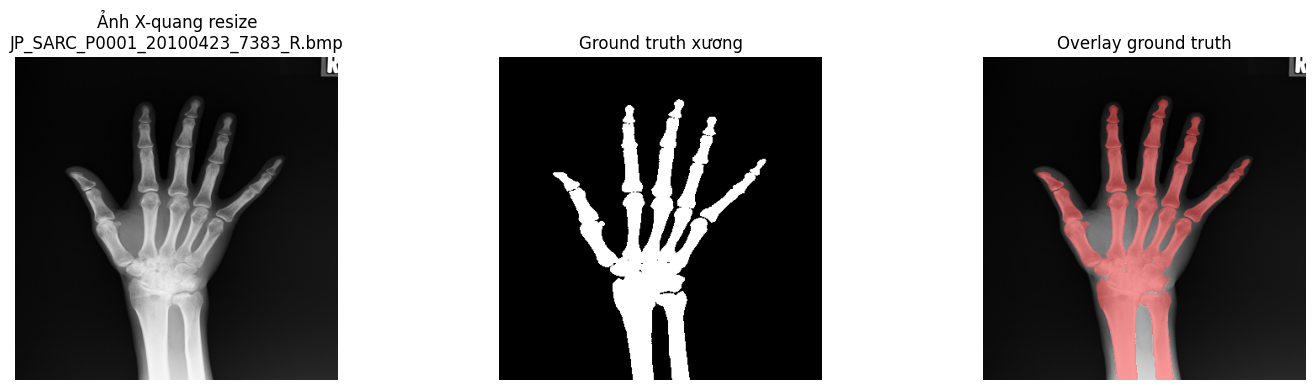

Ảnh đang debug: /content/drive/MyDrive/Thesis Experiment/Dataset/dataset/RAM-H1200-v1/Segmentation/val/JP_SARC_P0001_20100423_7383_R.bmp
Kích thước ảnh gốc: (1300, 1700)
Kích thước sau resize: (384, 384)
Số pixel xương trong GT: 21986


In [7]:
if dataset_ready:
    try:
        debug_ds = RAMH1200SegmentationDataset(root=RAM_ROOT, split=DEBUG_SPLIT, image_size=IMAGE_SIZE, augment=False)
    except Exception:
        DEBUG_SPLIT = 'validation'
        debug_ds = RAMH1200SegmentationDataset(root=RAM_ROOT, split=DEBUG_SPLIT, image_size=IMAGE_SIZE, augment=False)

    DEBUG_IMAGE_INDEX = max(0, min(DEBUG_IMAGE_INDEX, len(debug_ds) - 1))
    image_tensor_gt, gt_tensor, image_name = debug_ds[DEBUG_IMAGE_INDEX]
    sample_info = debug_ds.samples[DEBUG_IMAGE_INDEX]
    image_path = Path(sample_info['image_path'])

    original_pil = Image.open(image_path).convert('RGB')
    resized_pil = original_pil.resize((IMAGE_SIZE, IMAGE_SIZE))
    original_rgb = np.array(resized_pil)
    gt_mask = gt_tensor[0].numpy() > 0.5

    show_row([
        (f'Ảnh X-quang resize\n{image_name}', original_rgb, None),
        ('Ground truth xương', gt_mask, 'gray'),
        ('Overlay ground truth', overlay_mask(original_rgb, gt_mask), None),
    ], figsize=(15, 4))

    print('Ảnh đang debug:', image_path)
    print('Kích thước ảnh gốc:', original_pil.size)
    print('Kích thước sau resize:', resized_pil.size)
    print('Số pixel xương trong GT:', int(gt_mask.sum()))
else:
    print('Bỏ qua load ảnh vì dataset chưa sẵn sàng.')

## 5. Preprocessing ảnh cho classifier

Mục đích: kiểm tra ảnh trước/sau preprocessing để biết mô hình thật sự nhận đầu vào như thế nào.

Tham số của stage này:

- `USE_CLASSIFICATION_AUGMENT=False`: khi debug phải tắt augment để kết quả ổn định.
- `IMAGE_SIZE`: đã khai báo ở stage dataset. Nếu tăng, tensor có nhiều chi tiết hơn nhưng CAM/SAM chậm hơn.

Kết quả cần quan sát:

- ảnh resize trước transform;
- ảnh sau transform rồi chuyển ngược về RGB;
- thống kê min, max, mean của tensor.

Lỗi thường gặp: ảnh bị quá tối/quá sáng sau normalize, hoặc resize làm mất chi tiết xương nhỏ.

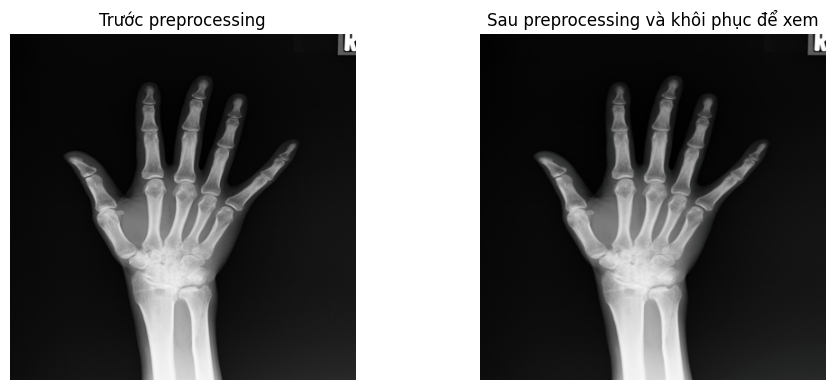

input_tensor shape: (1, 3, 384, 384)
min: -2.1007792949676514
max: 2.6225709915161133
mean: -1.2293962240219116


In [8]:
from datasets.common import make_classification_transform
from pseudo.visualization import tensor_to_pil

# Tắt augment để cùng một ảnh luôn cho cùng một tensor khi debug.
USE_CLASSIFICATION_AUGMENT = False

if dataset_ready:
    classification_transform = make_classification_transform(IMAGE_SIZE, augment=USE_CLASSIFICATION_AUGMENT)
    input_tensor_cpu = classification_transform(Image.open(image_path).convert('RGB')).unsqueeze(0)
    input_rgb = np.array(tensor_to_pil(input_tensor_cpu[0]))

    show_row([
        ('Trước preprocessing', original_rgb, None),
        ('Sau preprocessing và khôi phục để xem', input_rgb, None),
    ], figsize=(10, 4))

    print('input_tensor shape:', tuple(input_tensor_cpu.shape))
    print('min:', float(input_tensor_cpu.min()))
    print('max:', float(input_tensor_cpu.max()))
    print('mean:', float(input_tensor_cpu.mean()))
else:
    print('Bỏ qua preprocessing vì chưa có ảnh debug.')

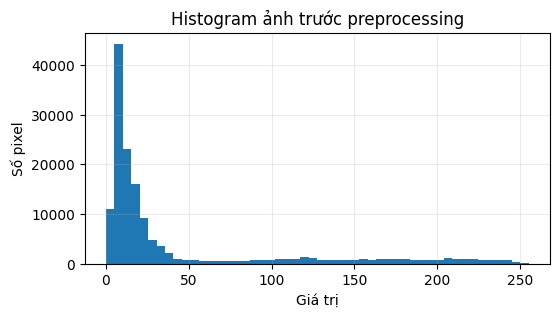

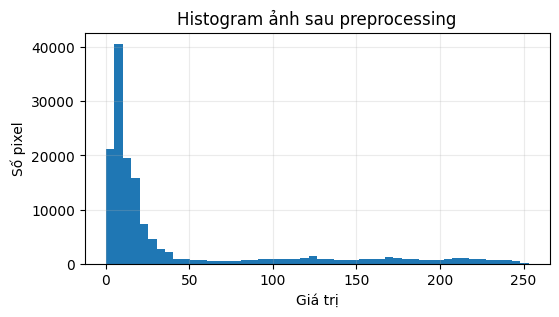

In [9]:
if dataset_ready:
    gray_before = np.asarray(resized_pil.convert('L'))
    gray_after = np.asarray(Image.fromarray(input_rgb).convert('L'))
    plot_histogram(gray_before, 'Histogram ảnh trước preprocessing')
    plot_histogram(gray_after, 'Histogram ảnh sau preprocessing')

## 6. Nạp checkpoint classifier

Mục đích: nạp DenseNet121 checkpoint để sinh prediction và LayerCAM.

Tham số của stage này:

- `CLASSIFIER_CHECKPOINT`: checkpoint classifier. Nếu không tồn tại, stage classifier/CAM sẽ được báo thiếu thay vì ép notebook crash.
- `TARGET_COLUMNS`: nhãn classifier. Với RAM-H1200 hiện tại là `hand`.
- `RUN_TRAIN_CLASSIFIER`: chỉ bật nếu thật sự chưa có checkpoint và bạn muốn train. Khi debug thường để `False`.

Ý nghĩa lệnh training nếu bật:

- `--image-size`: kích thước đầu vào. Tăng lên giữ chi tiết nhưng chậm hơn.
- `--batch-size`: tăng nếu GPU đủ VRAM, giảm nếu bị hết bộ nhớ.
- `--epochs`: tăng có thể cải thiện checkpoint nhưng không phù hợp khi chỉ debug pipeline.

In [10]:
from models.classifier import DenseNet121AnatomyClassifier
from generate_pseudo_masks import classifier_class_weights, tensor_to_rgb_numpy
import subprocess
import sys
import os
from pathlib import Path

TARGET_COLUMNS = ['hand']

# Bật True nếu muốn train classifier.
RUN_TRAIN_CLASSIFIER = True

# Số ảnh mỗi batch. Tăng lên nếu GPU còn dư VRAM, giảm xuống nếu bị out-of-memory.
BATCH_SIZE_CLASSIFIER = 4

# Số epoch train. Khi debug nhanh có thể để 1.
EPOCHS_CLASSIFIER = 1

# Trên Colab có thể để 2 hoặc 4. Nếu bị lỗi DataLoader thì để 0.
NUM_WORKERS_CLASSIFIER = 2

classifier_candidates = [
    OUTPUT_ROOT / 'classifier' / 'best_classifier.pt',
    WORKSPACE_ROOT / 'project' / 'outputs' / 'classifier' / 'best_classifier.pt',
    WORKSPACE_ROOT / 'outputs' / 'classifier' / 'best_classifier.pt',
]

CLASSIFIER_CHECKPOINT = next(
    (path for path in classifier_candidates if path.exists()),
    classifier_candidates[0]
)

train_classifier_cmd = [
    sys.executable, '-u', str(PROJECT_DIR / 'train_classifier.py'),
    '--ram-root', str(RAM_ROOT),
    '--train-split', 'train',
    '--val-split', DEBUG_SPLIT,
    '--target-columns', ','.join(TARGET_COLUMNS),
    '--image-size', str(IMAGE_SIZE),
    '--batch-size', str(BATCH_SIZE_CLASSIFIER),
    '--num-workers', str(NUM_WORKERS_CLASSIFIER),
    '--epochs', str(EPOCHS_CLASSIFIER),
    '--output-dir', str(OUTPUT_ROOT / 'classifier'),
]

print('Checkpoint classifier:', CLASSIFIER_CHECKPOINT)
print('Checkpoint tồn tại:', CLASSIFIER_CHECKPOINT.exists())
print('Lệnh train:')
print(' '.join(train_classifier_cmd))

if RUN_TRAIN_CLASSIFIER:
    print(f'\nBắt đầu train classifier trong {EPOCHS_CLASSIFIER} epoch...\n')

    env = os.environ.copy()
    env['PYTHONUNBUFFERED'] = '1'

    process = subprocess.Popen(
        train_classifier_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=env,
    )

    for line in process.stdout:
        print(line, end='')

    return_code = process.wait()

    if return_code != 0:
        raise RuntimeError(f'Train classifier thất bại với mã lỗi {return_code}')

    CLASSIFIER_CHECKPOINT = OUTPUT_ROOT / 'classifier' / 'best_classifier.pt'
    print('\nTrain classifier hoàn tất.')
    print('Checkpoint mới:', CLASSIFIER_CHECKPOINT)
else:
    print('Không train classifier vì RUN_TRAIN_CLASSIFIER=False.')

Checkpoint classifier: /content/drive/MyDrive/Thesis Experiment/debug_outputs/classifier/best_classifier.pt
Checkpoint tồn tại: False
Lệnh train:
/usr/bin/python3 -u /content/drive/MyDrive/Thesis Experiment/repo/project/train_classifier.py --ram-root /content/drive/MyDrive/Thesis Experiment/Dataset/dataset/RAM-H1200-v1 --train-split train --val-split val --target-columns hand --image-size 384 --batch-size 4 --num-workers 2 --epochs 1 --output-dir /content/drive/MyDrive/Thesis Experiment/debug_outputs/classifier

Bắt đầu train classifier trong 1 epoch...

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth

  0%|          | 0.00/30.8M [00:00<?, ?B/s]
 46%|████▌     | 14.2M/30.8M [00:00<00:00, 148MB/s]
 92%|█████████▏| 28.5M/30.8M [00:00<00:00, 146MB/s]
100%|██████████| 30.8M/30.8M [00:00<00:00, 146MB/s]
/content/drive/MyDrive/Thesis Experiment/repo/project/train_classifier.py:165: FutureWarning: `torc

In [11]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
classifier_ready = CLASSIFIER_CHECKPOINT.exists() and dataset_ready

if classifier_ready:
    checkpoint = torch.load(CLASSIFIER_CHECKPOINT, map_location='cpu')
    checkpoint_targets = checkpoint.get('target_columns', TARGET_COLUMNS)
    classifier_task = checkpoint.get('task', 'multi-label')

    classifier = DenseNet121AnatomyClassifier(num_classes=len(checkpoint_targets), pretrained=False)
    classifier.load_state_dict(checkpoint['model_state_dict'], strict=True)
    classifier.to(DEVICE).eval()
    input_tensor = input_tensor_cpu.to(DEVICE)
    input_rgb = tensor_to_rgb_numpy(input_tensor_cpu[0])

    print('Đã nạp classifier trên thiết bị:', DEVICE)
    print('Task:', classifier_task)
    print('Target columns:', checkpoint_targets)
else:
    print('Chưa thể nạp classifier. Kiểm tra dataset và CLASSIFIER_CHECKPOINT.')

Đã nạp classifier trên thiết bị: cuda
Task: multi-label
Target columns: ['hand']


## 7. Inference classifier

Mục đích: xem classifier dự đoán gì trước khi dùng nó để tạo CAM.

Tham số của stage này:

- `CONFIDENCE_THRESHOLD`: ngưỡng quyết định lớp nào đủ tin cậy để tham gia LayerCAM. Tăng ngưỡng làm CAM bảo thủ hơn; giảm ngưỡng giúp vẫn có CAM khi classifier chưa tự tin.

Kết quả cần quan sát:

- logit;
- probability hoặc class weight;
- lớp nào vượt ngưỡng;
- histogram xác suất nếu có nhiều lớp.

,lớp,logit,weight_dùng_cho_LayerCAM,qua_ngưỡng
0,hand,4.410365,0.987995,True


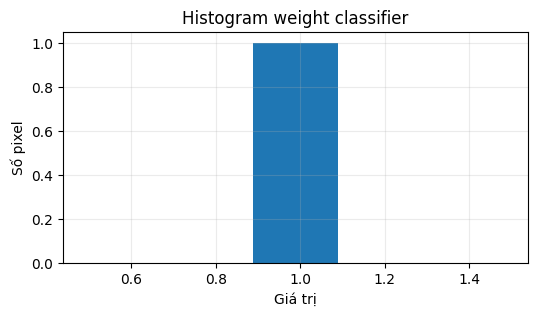

In [12]:
# Ngưỡng confidence cho classifier. Khi CAM không xuất hiện, thử giảm từ 0.5 xuống 0.3.
CONFIDENCE_THRESHOLD = 0.5

if classifier_ready:
    with torch.no_grad():
        logits = classifier(input_tensor)
    class_weights = classifier_class_weights(logits, classifier_task)

    classifier_rows = []
    for idx, target_name in enumerate(checkpoint_targets):
        classifier_rows.append({
            'lớp': target_name,
            'logit': float(logits[0, idx].detach().cpu()),
            'weight_dùng_cho_LayerCAM': float(class_weights[idx]),
            'qua_ngưỡng': bool(class_weights[idx] >= CONFIDENCE_THRESHOLD),
        })
    classifier_df = pd.DataFrame(classifier_rows)
    display(classifier_df)
    plot_histogram(class_weights, 'Histogram weight classifier', bins=max(5, len(class_weights)))
else:
    print('Bỏ qua inference classifier vì classifier chưa sẵn sàng.')

## 8. Sinh LayerCAM

Mục đích: tạo heatmap cho biết classifier chú ý vùng nào khi dự đoán.

Tham số của stage này:

- `CAM_CONFIDENCE_THRESHOLD`: lớp có weight thấp hơn ngưỡng này không tham gia fusion. Tăng lên giúp CAM ít nhiễu hơn; giảm xuống giúp tránh mất CAM khi classifier chưa đủ tự tin.

Kết quả cần quan sát:

- CAM riêng từng lớp nếu có;
- CAM hợp nhất;
- overlay CAM lên ảnh;
- histogram CAM để chọn threshold hợp lý ở stage sau.

Lỗi thường gặp: CAM bám toàn bàn tay thay vì vùng xương, hoặc CAM quá loãng khiến threshold khó chọn.

In [13]:
from models.layercam import LayerCAM
from pseudo.generate_layercam import generate_fused_cam

# Ngưỡng riêng cho CAM. Khi classifier yếu, thử giảm xuống 0.3.
CAM_CONFIDENCE_THRESHOLD = CONFIDENCE_THRESHOLD

cam_ready = False
if classifier_ready:
    layercam = LayerCAM(classifier, device=DEVICE)
    try:
        fused_cam, per_class_cams, active_indices = generate_fused_cam(
            layercam,
            input_tensor,
            class_weights=class_weights,
            confidence_threshold=CAM_CONFIDENCE_THRESHOLD,
        )
        cam_ready = True
    finally:
        layercam.close()

    print('Số lớp CAM hoạt động:', len(active_indices))
    print('active_indices:', active_indices)
    print('fused_cam min/max/mean:', float(fused_cam.min()), float(fused_cam.max()), float(fused_cam.mean()))
else:
    print('Bỏ qua LayerCAM vì classifier chưa sẵn sàng.')

Số lớp CAM hoạt động: 1
active_indices: [0]
fused_cam min/max/mean: 0.0 1.0 0.3087926208972931


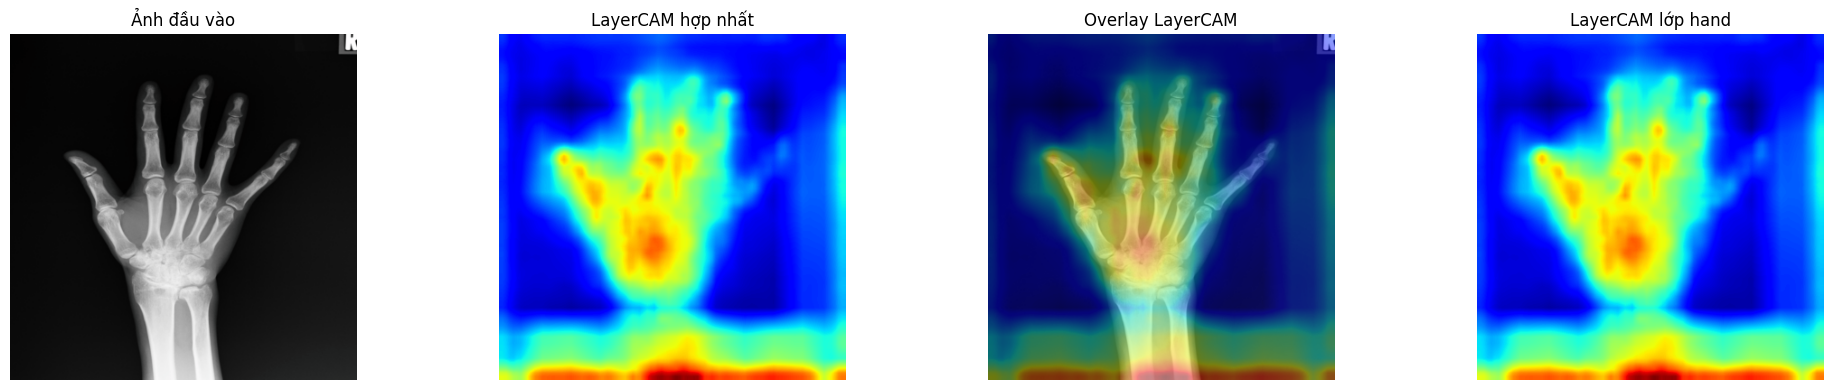

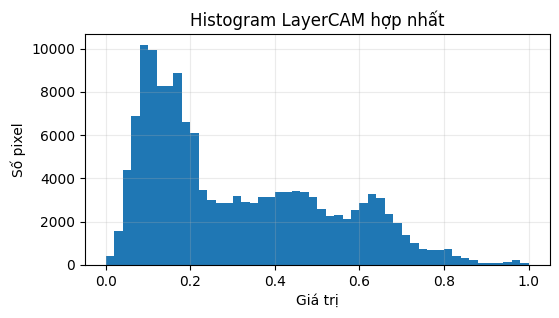

In [14]:
if cam_ready:
    items = [('Ảnh đầu vào', input_rgb, None), ('LayerCAM hợp nhất', fused_cam, 'jet'), ('Overlay LayerCAM', overlay_cam(input_rgb, fused_cam), None)]
    for local_idx, class_idx in enumerate(active_indices):
        class_name = checkpoint_targets[class_idx]
        items.append((f'LayerCAM lớp {class_name}', per_class_cams[local_idx], 'jet'))
    show_row(items, figsize=(5 * len(items), 4))
    plot_histogram(fused_cam, 'Histogram LayerCAM hợp nhất')

## 9. Threshold CAM và connected components

Mục đích: biến CAM liên tục thành vùng nhị phân để hiểu phần nào của ảnh đang được chọn.

Tham số của stage này:

- `CAM_PERCENTILE`: percentile dùng làm threshold. `85` nghĩa là giữ khoảng 15% pixel có CAM cao nhất. Tăng lên `90` làm vùng nhỏ và chắc hơn; giảm xuống `80` làm vùng rộng hơn nhưng dễ lấy nhiễu.
- `MIN_CAM_COMPONENT_AREA`: component CAM nhỏ hơn ngưỡng này được xem là nhiễu khi phân tích. Tăng lên bỏ nhiễu tốt hơn nhưng có thể mất vùng xương nhỏ.

Kết quả cần quan sát:

- CAM heatmap;
- CAM nhị phân sau threshold;
- component được tô màu;
- bảng diện tích từng component.

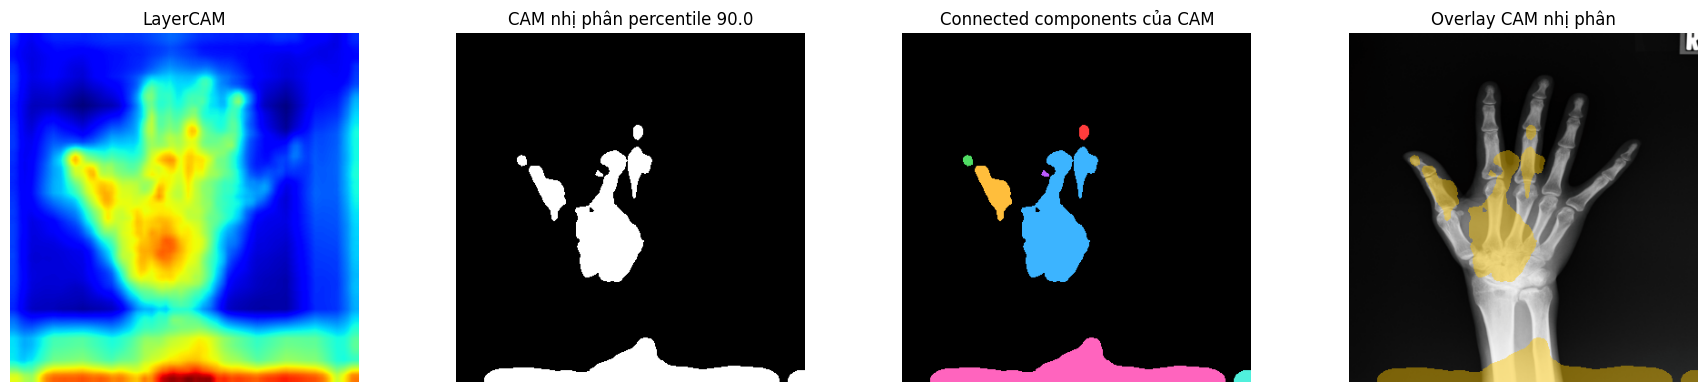

,component_id,diện_tích_pixel,x_min,y_min,x_max,y_max,giữ_lại_theo_diện_tích
0,0,149,195,101,205,117,True
1,1,6852,131,125,215,273,True
2,2,106,67,134,77,146,True
3,3,1144,80,146,120,206,True
4,4,40,153,151,161,157,False
5,5,6246,31,335,355,383,True
6,6,209,365,371,383,383,True


Threshold CAM: 0.6360747814178467


In [16]:
CAM_PERCENTILE = 90.0
MIN_CAM_COMPONENT_AREA = 100

cam_binary_ready = False
if cam_ready:
    cam_threshold = float(np.percentile(fused_cam, CAM_PERCENTILE))
    cam_binary = fused_cam >= cam_threshold
    cam_components_image, cam_components_df = visualize_connected_components(cam_binary)
    cam_components_df['giữ_lại_theo_diện_tích'] = cam_components_df['diện_tích_pixel'] >= MIN_CAM_COMPONENT_AREA
    cam_binary_ready = True

    show_row([
        ('LayerCAM', fused_cam, 'jet'),
        (f'CAM nhị phân percentile {CAM_PERCENTILE}', cam_binary, 'gray'),
        ('Connected components của CAM', cam_components_image, None),
        ('Overlay CAM nhị phân', overlay_mask(input_rgb, cam_binary, color=(255, 200, 0), alpha=0.45), None),
    ], figsize=(18, 4))
    display(cam_components_df)
    print('Threshold CAM:', cam_threshold)
else:
    print('Bỏ qua threshold CAM vì chưa có CAM.')

## 10. Tạo bản đồ intensity và edge trước morphology

Mục đích: tách riêng phần xử lý ảnh X-quang trước khi tạo pseudo mask.

Các phép xử lý:

- `_enhance_grayscale`: chuyển ảnh sang xám, tăng tương phản bằng CLAHE nếu có OpenCV, chuẩn hóa về `[0, 1]`.
- `_cortical_edge_response`: dùng Sobel hoặc gradient để nhấn mạnh biên vỏ xương.

Tham số của stage này:

- `USE_CLAHE=True`: làm rõ tương phản cục bộ. Tắt đi nếu CLAHE làm nhiễu sáng quá mạnh.

Kết quả cần quan sát: ảnh xám tăng cường, edge response và histogram của từng bản đồ.

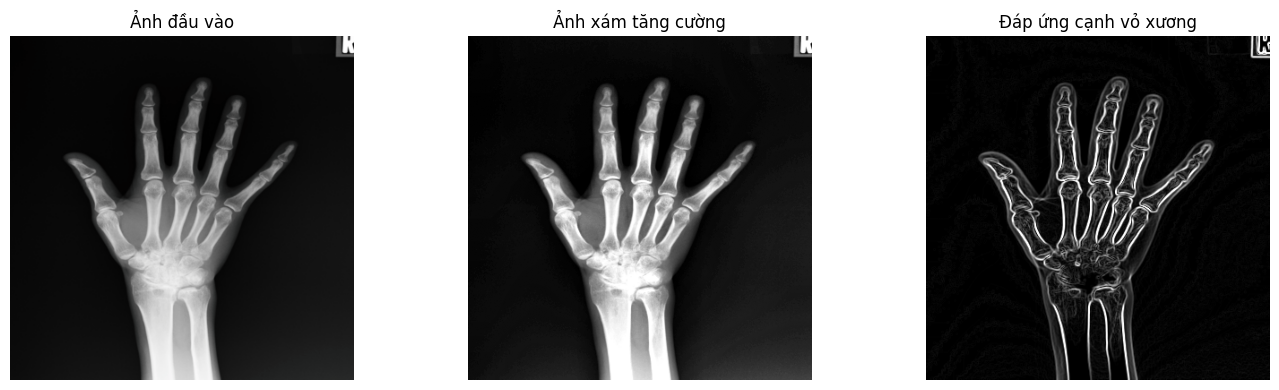

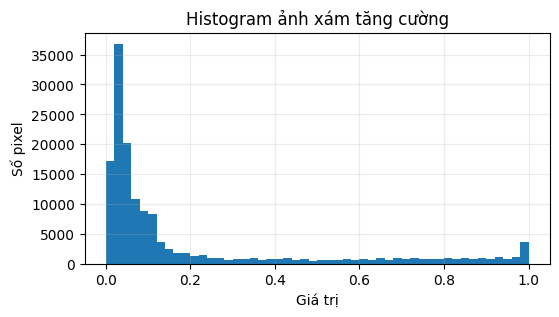

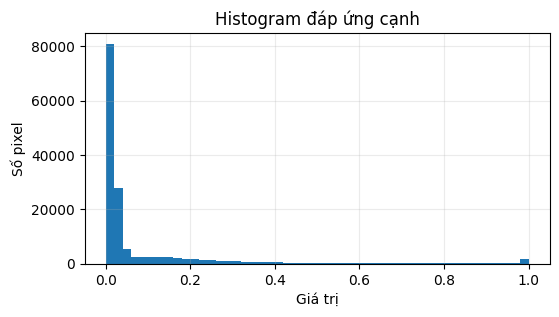

In [17]:
from pseudo.bone_morphology import _enhance_grayscale, _cortical_edge_response

USE_CLAHE = True

image_processing_ready = False
if cam_ready:
    enhanced_gray = _enhance_grayscale(input_rgb, use_clahe=USE_CLAHE)
    cortical_edge = _cortical_edge_response(enhanced_gray)
    image_processing_ready = True

    show_row([
        ('Ảnh đầu vào', input_rgb, None),
        ('Ảnh xám tăng cường', enhanced_gray, 'gray'),
        ('Đáp ứng cạnh vỏ xương', cortical_edge, 'gray'),
    ], figsize=(14, 4))
    plot_histogram(enhanced_gray, 'Histogram ảnh xám tăng cường')
    plot_histogram(cortical_edge, 'Histogram đáp ứng cạnh')
else:
    print('Bỏ qua xử lý ảnh vì chưa có CAM và ảnh đầu vào hợp lệ.')

## 11. Bone likelihood, seed, support và reconstruction

Mục đích: tạo vùng gợi ý xương trước SAM bằng cách kết hợp intensity, edge và CAM.

Công thức trong project:

```python
bone_likelihood = 0.58 * intensity + 0.32 * edge + 0.10 * cam
```

Tham số của stage này:

- `BONE_SEED_PERCENTILE`: percentile lấy seed chắc chắn. Tăng lên làm seed ít hơn và bảo thủ hơn; giảm xuống làm seed nhiều hơn nhưng dễ nhiễu.
- `BONE_SUPPORT_PERCENTILE`: percentile lấy vùng support. Tăng lên support hẹp hơn; giảm xuống support rộng hơn và dễ tràn sang mô mềm.
- `MORPH_MIN_COMPONENT_AREA`: component nhỏ hơn ngưỡng này bị loại trong morphology.
- `MORPH_MAX_COMPONENTS`: số component tối đa giữ lại.

Kết quả cần quan sát: bone likelihood, seed preview, support preview, support sau reconstruction và metric nếu so với ground truth.

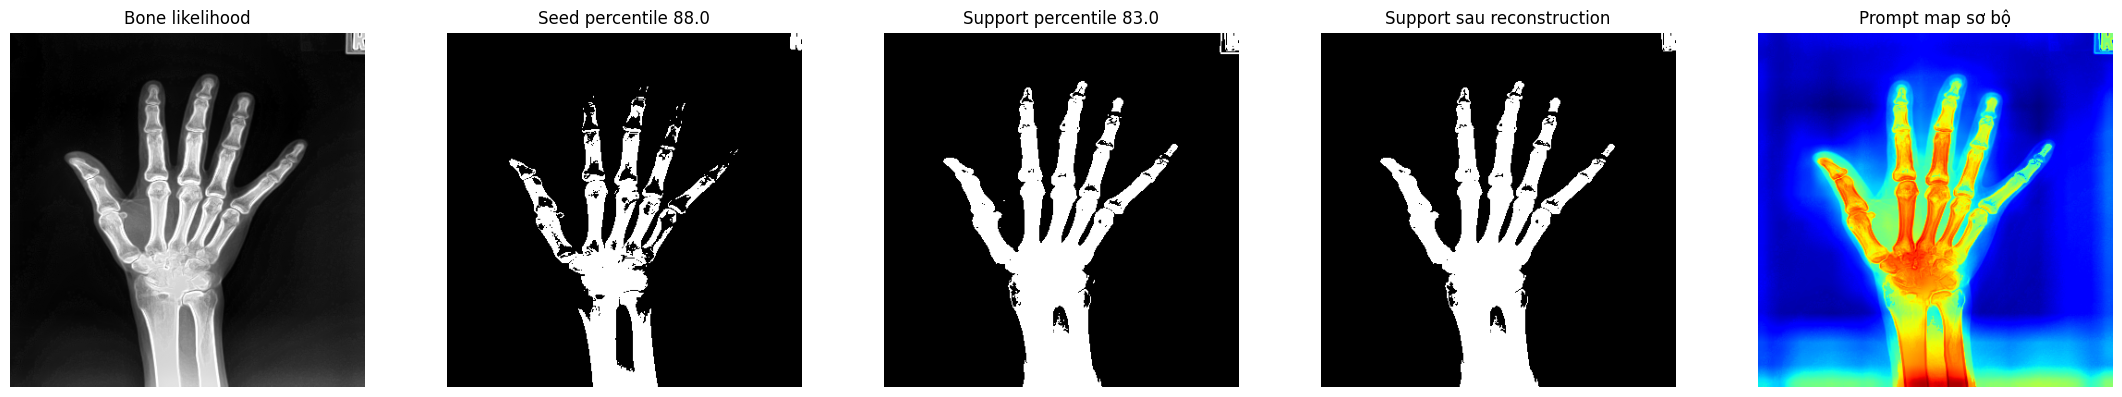

,mask,Dice,IoU,Precision,Recall,Foreground_%,Background_%,TP,FP,FN,pred_pixels,gt_pixels
0,seed_preview,0.811068,0.682182,0.909409,0.731920,12.000190,87.999810,16092,1603,5894,17695,21986
1,support_preview,0.897650,0.814305,0.842468,0.960566,17.000326,82.999674,21119,3949,867,25068,21986
2,bone_support_simple,0.899099,0.816694,0.845519,0.959929,16.927762,83.072238,21105,3856,881,24961,21986


In [29]:
from pseudo.bone_morphology import build_bone_guidance, fuse_cam_with_bone_guidance

BONE_SEED_PERCENTILE = 88.0
BONE_SUPPORT_PERCENTILE = 83.0
MORPH_MIN_COMPONENT_AREA = 25
MORPH_MAX_COMPONENTS = 5

bone_guidance_ready = False
if image_processing_ready:
    bone_likelihood, bone_support_simple = build_bone_guidance(
        input_rgb,
        fused_cam,
        seed_percentile=BONE_SEED_PERCENTILE,
        support_percentile=BONE_SUPPORT_PERCENTILE,
        min_component_area=MORPH_MIN_COMPONENT_AREA,
        max_components=MORPH_MAX_COMPONENTS,
    )
    seed_threshold = float(np.percentile(bone_likelihood, BONE_SEED_PERCENTILE))
    support_threshold = float(max(np.percentile(bone_likelihood, BONE_SUPPORT_PERCENTILE), np.percentile(bone_likelihood, 68.0)))
    seed_preview = bone_likelihood >= seed_threshold
    support_preview = bone_likelihood >= support_threshold
    prompt_map_simple = fuse_cam_with_bone_guidance(fused_cam, bone_likelihood, bone_support_simple)
    bone_guidance_ready = True

    show_row([
        ('Bone likelihood', bone_likelihood, 'gray'),
        (f'Seed percentile {BONE_SEED_PERCENTILE}', seed_preview, 'gray'),
        (f'Support percentile {BONE_SUPPORT_PERCENTILE}', support_preview, 'gray'),
        ('Support sau reconstruction', bone_support_simple, 'gray'),
        ('Prompt map sơ bộ', prompt_map_simple, 'jet'),
    ], figsize=(22, 4))

    display(pd.DataFrame([
        {'mask': 'seed_preview', **binary_metrics_np(seed_preview, gt_mask)},
        {'mask': 'support_preview', **binary_metrics_np(support_preview, gt_mask)},
        {'mask': 'bone_support_simple', **binary_metrics_np(bone_support_simple, gt_mask)},
    ]))
else:
    print('Bỏ qua bone guidance vì xử lý ảnh chưa sẵn sàng.')

## 12. Chọn bone components theo CAM và morphology

Mục đích: chọn các vùng xương ứng viên để đưa sang SAM.

Tham số của stage này:

- `COMPONENT_MIN_AREA`: diện tích tối thiểu. Tăng lên loại nhiễu tốt hơn nhưng có thể mất xương nhỏ.
- `MAX_BONE_COMPONENTS`: số component tối đa. Tăng lên đầy đủ hơn nhưng SAM chậm hơn.
- `POINTS_PER_COMPONENT`: số điểm dương cho mỗi component. Tăng lên giúp mô tả xương dài tốt hơn.
- `BBOX_PADDING_RATIO`: nới bbox quanh component. Tăng lên cho SAM thêm ngữ cảnh nhưng dễ lấy mô mềm.

Kết quả cần quan sát:

- bảng component;
- component overlay;
- bbox và điểm prompt.

In [30]:
from pseudo.bone_morphology import build_class_conditioned_components

COMPONENT_MIN_AREA = 50
MAX_BONE_COMPONENTS = 12
POINTS_PER_COMPONENT = 3
BBOX_PADDING_RATIO = 0.02

components_ready = False
if bone_guidance_ready:
    active_weights = [float(class_weights[i]) for i in active_indices]
    if not per_class_cams:
        per_class_cams = [fused_cam]
        active_weights = [1.0]

    bone_likelihood, bone_support, bone_components = build_class_conditioned_components(
        input_rgb,
        per_class_cams,
        active_weights,
        seed_percentile=BONE_SEED_PERCENTILE,
        support_percentile=BONE_SUPPORT_PERCENTILE,
        min_component_area=COMPONENT_MIN_AREA,
        max_components=MAX_BONE_COMPONENTS,
        points_per_component=POINTS_PER_COMPONENT,
        bbox_padding_ratio=BBOX_PADDING_RATIO,
    )
    prompt_map = fuse_cam_with_bone_guidance(fused_cam, bone_likelihood, bone_support)
    components_ready = len(bone_components) > 0

    component_rows = []
    for component in bone_components:
        component_rows.append({
            'component_id': component.component_id,
            'score': component.score,
            'diện_tích_pixel': int(component.mask.sum()),
            'bbox_x0_y0_x1_y1': component.bbox,
            'positive_points_row_col': component.positive_points,
        })
    display(pd.DataFrame(component_rows))
else:
    print('Bỏ qua chọn component vì bone guidance chưa sẵn sàng.')

,component_id,score,diện_tích_pixel,bbox_x0_y0_x1_y1,positive_points_row_col
0,0,0.615183,24439,"(60, 47, 311, 383)","((383, 206), (232, 183), (168, 148))"
1,1,0.234536,141,"(244, 69, 260, 88)","((82, 248), (77, 258))"
2,2,0.228834,285,"(366, 0, 383, 22)","((0, 380), (10, 376))"
3,3,0.188656,96,"(301, 119, 319, 136)","((128, 313),)"


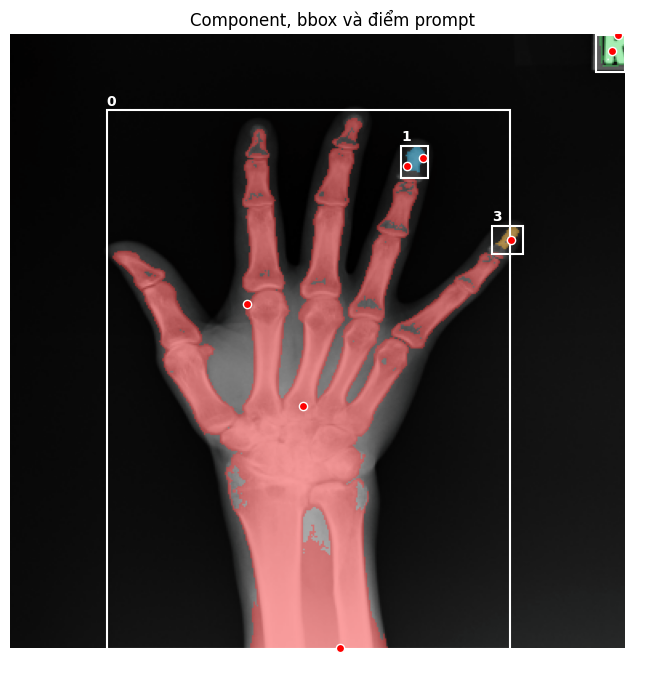

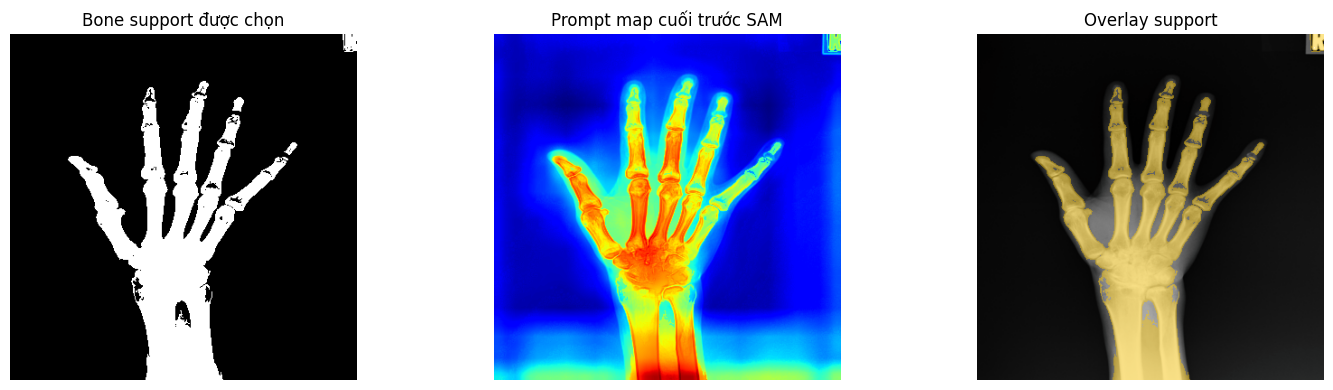

In [31]:
if bone_guidance_ready:
    component_overlay = input_rgb.copy()
    colors = np.array([[255,50,50], [50,200,255], [60,220,90], [255,180,40], [190,80,255], [255,90,180], [80,240,220]], dtype=np.uint8)
    for component in bone_components:
        mask_bool = component.mask.astype(bool)
        color = colors[component.component_id % len(colors)]
        component_overlay[mask_bool] = (0.55 * component_overlay[mask_bool] + 0.45 * color).astype(np.uint8)

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(component_overlay)
    for component in bone_components:
        x0, y0, x1, y1 = component.bbox
        ax.add_patch(plt.Rectangle((x0, y0), x1 - x0 + 1, y1 - y0 + 1, fill=False, color='white', linewidth=1.5))
        ax.text(x0, max(0, y0 - 3), str(component.component_id), color='white', fontsize=10, weight='bold')
        for row, col in component.positive_points:
            ax.scatter([col], [row], c='red', s=35, edgecolors='white')
    ax.set_title('Component, bbox và điểm prompt')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    show_row([
        ('Bone support được chọn', bone_support, 'gray'),
        ('Prompt map cuối trước SAM', prompt_map, 'jet'),
        ('Overlay support', overlay_mask(input_rgb, bone_support.astype(bool), color=(255, 200, 0), alpha=0.45), None),
    ], figsize=(15, 4))

## 13. Prompt extraction dạng point từ prompt map

Mục đích: xem prompt point nếu không dùng component bbox. Stage này giúp so sánh đường prompt dựa trên map với đường prompt dựa trên component.

Tham số của stage này:

- `POINT_PROMPT_PERCENTILE`: threshold trên prompt map để lấy điểm. Tăng lên lấy điểm chắc hơn nhưng ít hơn; giảm xuống lấy nhiều vùng hơn nhưng dễ nhiễu.
- `MAX_POINT_PROMPTS`: số điểm tối đa. Tăng lên cho SAM nhiều gợi ý hơn nhưng chạy chậm hơn.
- `POINT_MIN_COMPONENT_AREA`: component nhỏ hơn ngưỡng này không sinh point.

Kết quả cần quan sát: điểm prompt có nằm trên xương không, có bị rơi vào nền/mô mềm không.

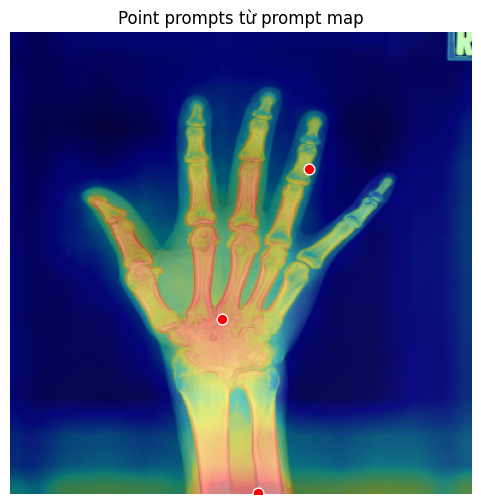

point_prompts: [(383, 206), (238, 176), (113, 248)]


In [32]:
from pseudo.extract_prompts import extract_point_prompts

POINT_PROMPT_PERCENTILE = 85.0
MAX_POINT_PROMPTS = 5
POINT_MIN_COMPONENT_AREA = 100

point_prompts = []
if bone_guidance_ready:
    point_prompts = extract_point_prompts(
        prompt_map,
        cam_percentile=POINT_PROMPT_PERCENTILE,
        max_points=MAX_POINT_PROMPTS,
        min_component_area=POINT_MIN_COMPONENT_AREA,
        support_mask=bone_support,
    )
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.imshow(overlay_cam(input_rgb, prompt_map))
    for row, col in point_prompts:
        ax.scatter([col], [row], c='red', s=60, edgecolors='white')
    ax.set_title('Point prompts từ prompt map')
    ax.axis('off')
    plt.show()
    print('point_prompts:', point_prompts)
else:
    print('Bỏ qua prompt extraction vì chưa có prompt map.')

## 14. Chạy SAM trên component prompt

Mục đích: dùng bbox/point từ component để SAM sinh các mask ứng viên.

Tham số của stage này:

- `SAM_CHECKPOINT`: file checkpoint SAM ViT-B.
- `SAM_PROMPT_MODE`: `point`, `joint_points`, `box`, hoặc `box_point`. `box_point` thường ổn định hơn vì có cả vùng bao và điểm dương.
- `SAM_SINGLE_MASK`: nếu `False`, SAM trả nhiều ứng viên để chấm điểm. Nếu `True`, nhanh hơn nhưng ít lựa chọn hơn.
- `NEGATIVE_POINTS_PER_COMPONENT`: số điểm âm quanh bbox. Tăng lên có thể giảm tràn mask nhưng điểm âm sai có thể cắt mất xương.

Kết quả cần quan sát: số mask ứng viên, score gốc của SAM và mask nào bị tràn sang mô mềm.

In [39]:
from pseudo.sam_refine import SAMPredictor

SAM_CHECKPOINT = WORKSPACE_ROOT / 'sam_vit_b_01ec64.pth'
SAM_PROMPT_MODE = 'box_point'
SAM_SINGLE_MASK = False
NEGATIVE_POINTS_PER_COMPONENT = 0

sam_ready = False
if not SAM_CHECKPOINT.exists():
    print('Thiếu checkpoint SAM:', SAM_CHECKPOINT)
elif not components_ready:
    print('Chưa có component hợp lệ để đưa vào SAM.')
else:
    sam_predictor = SAMPredictor(
        checkpoint_path=SAM_CHECKPOINT,
        auto_download=False,
        device=str(DEVICE),
    )
    sam_masks, sam_scores, component_ids = sam_predictor.predict_from_components(
        input_rgb,
        bone_components,
        prompt_mode=SAM_PROMPT_MODE,
        multimask_output=not SAM_SINGLE_MASK,
        negative_points_per_component=NEGATIVE_POINTS_PER_COMPONENT,
    )
    sam_ready = sam_masks.shape[0] > 0
    print('Số mask ứng viên:', sam_masks.shape[0])
    print('sam_scores:', sam_scores)
    print('component_ids:', component_ids)

Số mask ứng viên: 12
sam_scores: [1.0034101  0.9766267  0.850719   0.9071817  0.91604114 0.91298485
 0.95971876 0.96926135 0.9615804  0.930633   0.9292849  0.92208016]
component_ids: [0 0 0 1 1 1 2 2 2 3 3 3]


## 15. Phân tích từng mask ứng viên của SAM

Mục đích: chấm điểm từng mask ứng viên và xem bằng mắt mask nào tốt/xấu.

Tham số của stage này:

- `SELECTION_METHOD`: cách chấm điểm mask. `bone_hybrid` dùng CAM, bone likelihood, support, score SAM và penalty mask lớn.

Kết quả cần quan sát:

- `sam_score`: score gốc của SAM;
- `selection_score`: score theo pipeline;
- Dice/IoU tạm với ground truth;
- overlay từng mask ứng viên.

In [40]:
from pseudo.mask_selection import score_masks

SELECTION_METHOD = 'bone_hybrid'

sam_candidate_ready = False
if sam_ready:
    selection_scores = score_masks(
        sam_masks,
        fused_cam,
        method=SELECTION_METHOD,
        bone_likelihood=bone_likelihood,
        bone_support=bone_support,
        sam_scores=sam_scores,
    )

    candidate_rows = []
    for idx in range(sam_masks.shape[0]):
        mask_bool = sam_masks[idx].astype(bool)
        candidate_rows.append({
            'mask_id': idx,
            'component_id': int(component_ids[idx]) if component_ids.size else None,
            'sam_score': float(sam_scores[idx]),
            'selection_score': float(selection_scores[idx]),
            'diện_tích_pixel': int(mask_bool.sum()),
            **binary_metrics_np(mask_bool, gt_mask),
        })
    candidate_df = pd.DataFrame(candidate_rows).sort_values('selection_score', ascending=False)
    display(candidate_df)
    sam_candidate_ready = True
else:
    print('Bỏ qua phân tích SAM vì SAM chưa có mask ứng viên.')

,mask_id,component_id,sam_score,selection_score,diện_tích_pixel,Dice,IoU,Precision,Recall,Foreground_%,Background_%,TP,FP,FN,pred_pixels,gt_pixels
2,2,0,0.850719,0.773853,32742,7.995907e-01,6.660984e-01,0.668255,0.995179,22.204590,77.795410,21880,10862,106,32742,21986
1,1,0,0.976627,0.752075,37219,7.427075e-01,5.907198e-01,0.590720,1.000000,25.240750,74.759250,21986,15233,0,37219,21986
0,0,0,1.003410,0.750788,37711,7.365864e-01,5.830129e-01,0.583013,1.000000,25.574409,74.425591,21986,15725,0,37711,21986
8,8,2,0.961580,0.601547,258,4.495594e-11,4.495594e-11,0.000000,0.000000,0.174967,99.825033,0,258,21986,258,21986
7,7,2,0.969261,0.561656,290,4.489136e-11,4.489136e-11,0.000000,0.000000,0.196669,99.803331,0,290,21986,290,21986
5,5,1,0.912985,0.467508,241,2.051559e-02,1.036411e-02,0.946058,0.010370,0.163439,99.836561,228,13,21758,241,21986
6,6,2,0.959719,0.457403,477,4.451765e-11,4.451765e-11,0.000000,0.000000,0.323486,99.676514,0,477,21986,477,21986
4,4,1,0.916041,0.448802,262,2.085581e-02,1.053779e-02,0.885496,0.010552,0.177680,99.822320,232,30,21754,262,21986
11,11,3,0.922080,0.410490,199,1.496507e-02,7.538944e-03,0.834171,0.007550,0.134956,99.865044,166,33,21820,199,21986
3,3,1,0.907182,0.378936,326,2.088562e-02,1.055301e-02,0.714724,0.010598,0.221083,99.778917,233,93,21753,326,21986


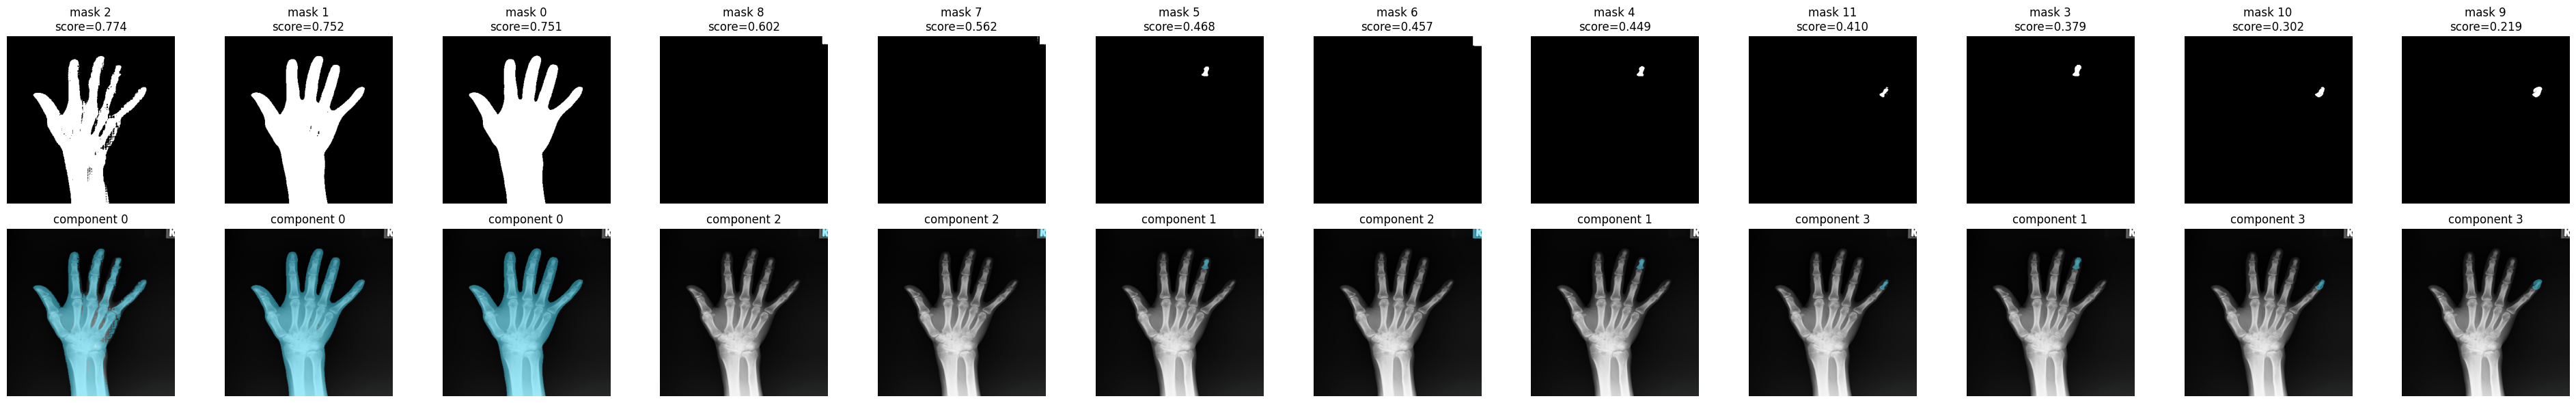

In [41]:
if sam_candidate_ready:
    max_show = min(12, sam_masks.shape[0])
    fig, axes = plt.subplots(2, max_show, figsize=(3.2 * max_show, 6))
    if max_show == 1:
        axes = np.array([[axes[0]], [axes[1]]])
    for col, idx in enumerate(candidate_df['mask_id'].head(max_show).tolist()):
        mask_bool = sam_masks[idx].astype(bool)
        axes[0, col].imshow(mask_bool, cmap='gray')
        axes[0, col].set_title(f'mask {idx}\nscore={selection_scores[idx]:.3f}')
        axes[0, col].axis('off')
        axes[1, col].imshow(overlay_mask(input_rgb, mask_bool, color=(50, 220, 255), alpha=0.45))
        axes[1, col].set_title(f'component {int(component_ids[idx]) if component_ids.size else "?"}')
        axes[1, col].axis('off')
    plt.tight_layout()
    plt.show()

## 16. Chọn và hợp nhất pseudo mask từ SAM

Mục đích: biến nhiều mask ứng viên thành một pseudo mask thô trước hậu xử lý.

Tham số của stage này:

- `MASK_SCORE_THRESHOLD`: mask dưới ngưỡng bị loại. Tăng lên sạch hơn nhưng dễ thiếu xương; giảm xuống đầy đủ hơn nhưng dễ nhiễu.
- `FUSION_TOPK`: số mask tốt nhất được hợp nhất. `1` chỉ lấy mask tốt nhất, `3` lấy hợp của 3 mask tốt nhất, `0` lấy tất cả mask vượt ngưỡng.
- `BEST_PER_COMPONENT=True`: chọn mask tốt nhất cho từng component trước khi hợp nhất, phù hợp khi prompt theo component.

Kết quả cần quan sát: pseudo mask thô có bị tràn toàn bàn tay hay thiếu nhiều xương không.

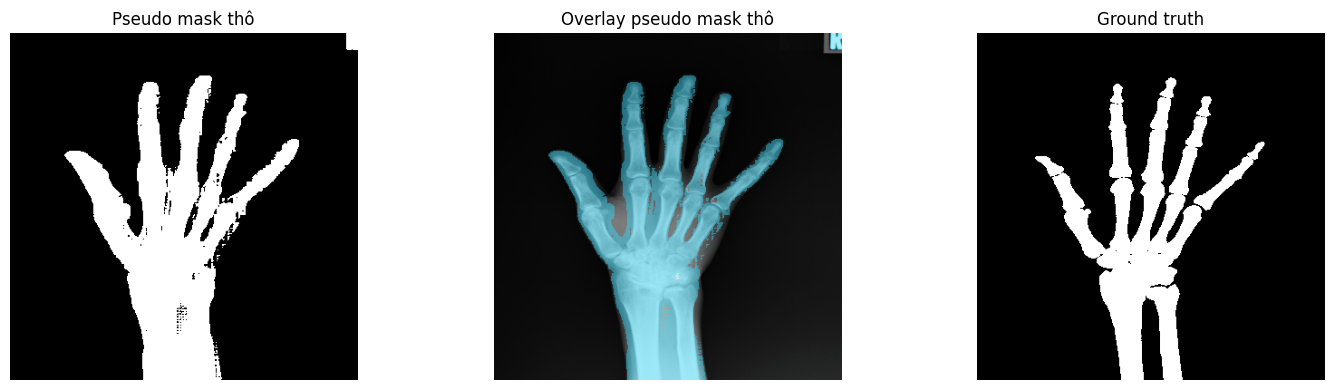

,stage,Dice,IoU,Precision,Recall,Foreground_%,Background_%,TP,FP,FN,pred_pixels,gt_pixels
0,raw_pseudo_mask,0.818719,0.693077,0.695279,0.995452,21.347385,78.652615,21886,9592,100,31478,21986


In [42]:
from pseudo.mask_selection import select_and_fuse_masks

MASK_SCORE_THRESHOLD = 0.4
FUSION_TOPK = 3
BEST_PER_COMPONENT = True

raw_pseudo_ready = False
if sam_candidate_ready:
    component_masks = np.stack([component.mask for component in bone_components]) if bone_components else None
    raw_pseudo_mask = select_and_fuse_masks(
        sam_masks,
        fused_cam,
        mask_score_threshold=MASK_SCORE_THRESHOLD,
        selection_method=SELECTION_METHOD,
        fusion_topk=FUSION_TOPK,
        bone_likelihood=bone_likelihood,
        bone_support=bone_support,
        sam_scores=sam_scores,
        component_ids=component_ids,
        component_masks=component_masks,
        best_per_component=BEST_PER_COMPONENT,
    )
    raw_pseudo_ready = True

    show_row([
        ('Pseudo mask thô', raw_pseudo_mask, 'gray'),
        ('Overlay pseudo mask thô', overlay_mask(input_rgb, raw_pseudo_mask.astype(bool), color=(50, 220, 255), alpha=0.45), None),
        ('Ground truth', gt_mask, 'gray'),
    ], figsize=(15, 4))
    display(pd.DataFrame([{'stage': 'raw_pseudo_mask', **binary_metrics_np(raw_pseudo_mask, gt_mask)}]))
else:
    print('Bỏ qua chọn mask vì chưa có SAM candidate.')

## 17. Hậu xử lý morphology cho pseudo mask

Mục đích: làm sạch pseudo mask sau SAM.

Các phép xử lý:

- `binary_closing`: giãn rồi co, giúp nối khe nhỏ và lấp đứt gãy. Kernel lớn nối mạnh hơn nhưng dễ dính các xương gần nhau.
- `binary_opening`: co rồi giãn, giúp bỏ nhiễu mảnh. Kernel lớn bỏ nhiễu mạnh hơn nhưng dễ làm mất xương nhỏ.
- `fill_holes`: lấp lỗ kín nhỏ hơn `MAX_HOLE_AREA`.
- `remove_small_objects`: bỏ component nhỏ hơn `MIN_FINAL_SIZE`.
- `morphological_refinement`: chạy pipeline hậu xử lý đầy đủ và có lọc bằng guidance map.

Tham số của stage này đặt ngay bên dưới để bạn thử nhanh khi mask thô xấu.

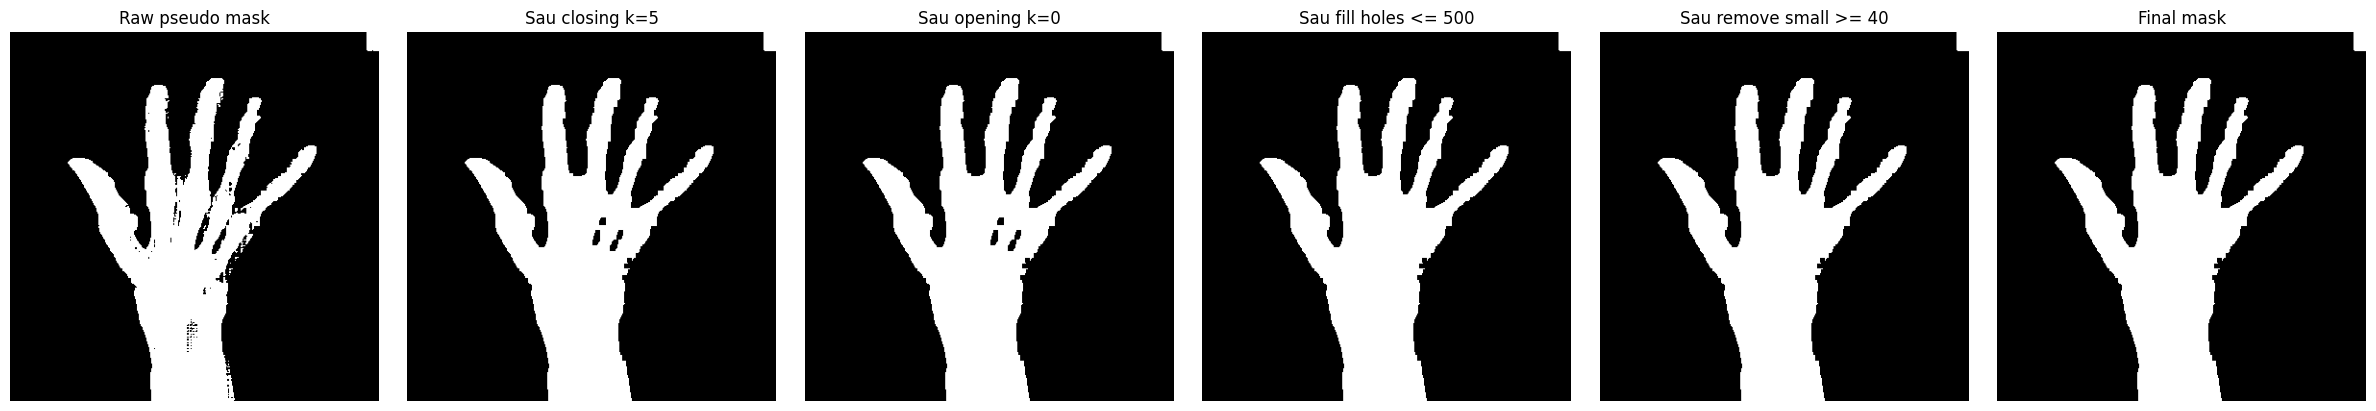

,stage,Dice,IoU,Precision,Recall,Foreground_%,Background_%,TP,FP,FN,pred_pixels,gt_pixels
0,Raw pseudo mask,0.818719,0.693077,0.695279,0.995452,21.347385,78.652615,21886,9592,100,31478,21986
1,Sau closing k=5,0.807641,0.677348,0.677390,0.999909,22.009277,77.990723,21984,10470,2,32454,21986
2,Sau opening k=0,0.807641,0.677348,0.677390,0.999909,22.009277,77.990723,21984,10470,2,32454,21986
3,Sau fill holes <= 500,0.803318,0.671288,0.671329,0.999909,22.207981,77.792019,21984,10763,2,32747,21986
4,Sau remove small >= 40,0.803318,0.671288,0.671329,0.999909,22.207981,77.792019,21984,10763,2,32747,21986
5,Final mask,0.803318,0.671288,0.671329,0.999909,22.207981,77.792019,21984,10763,2,32747,21986


In [43]:
from pseudo.morphology import binary_closing, binary_opening, fill_holes, remove_small_objects, morphological_refinement

CLOSING_KERNEL = 5
OPENING_KERNEL = 0
MAX_HOLE_AREA = 500
MIN_FINAL_SIZE = 40
GUIDANCE_THRESHOLD = 0.20

final_ready = False
if raw_pseudo_ready:
    after_closing = binary_closing(raw_pseudo_mask, kernel_size=CLOSING_KERNEL) if CLOSING_KERNEL > 1 else raw_pseudo_mask.copy()
    after_opening = binary_opening(after_closing, kernel_size=OPENING_KERNEL) if OPENING_KERNEL > 1 else after_closing.copy()
    after_fill_holes = fill_holes(after_opening, max_hole_area=MAX_HOLE_AREA)
    after_remove_small = remove_small_objects(after_fill_holes, min_size=MIN_FINAL_SIZE)
    final_mask = morphological_refinement(
        raw_pseudo_mask,
        closing_kernel=CLOSING_KERNEL,
        opening_kernel=OPENING_KERNEL,
        min_size=MIN_FINAL_SIZE,
        guidance_map=bone_likelihood,
        guidance_threshold=GUIDANCE_THRESHOLD,
        max_hole_area=MAX_HOLE_AREA,
    )
    final_ready = True

    mask_steps = [
        ('Raw pseudo mask', raw_pseudo_mask),
        (f'Sau closing k={CLOSING_KERNEL}', after_closing),
        (f'Sau opening k={OPENING_KERNEL}', after_opening),
        (f'Sau fill holes <= {MAX_HOLE_AREA}', after_fill_holes),
        (f'Sau remove small >= {MIN_FINAL_SIZE}', after_remove_small),
        ('Final mask', final_mask),
    ]
    show_row([(title, mask, 'gray') for title, mask in mask_steps], figsize=(24, 4))
    display(pd.DataFrame([{'stage': title, **binary_metrics_np(mask, gt_mask)} for title, mask in mask_steps]))
else:
    print('Bỏ qua hậu xử lý vì chưa có pseudo mask thô.')

## 18. Evaluation cuối trên ảnh đang debug

Mục đích: nhìn kết quả cuối cùng bằng cả hình và số.

Kết quả:

- Dice;
- IoU;
- precision;
- recall;
- foreground ratio;
- bản đồ lỗi: đúng dương, dự đoán dư, dự đoán thiếu.

Khi chỉ số thấp, hãy nhìn bản đồ lỗi để biết nên chỉnh CAM, morphology, SAM hay hậu xử lý.

,stage,Dice,IoU,Precision,Recall,Foreground_%,Background_%,TP,FP,FN,pred_pixels,gt_pixels
0,final_mask,0.803318,0.671288,0.671329,0.999909,22.207981,77.792019,21984,10763,2,32747,21986


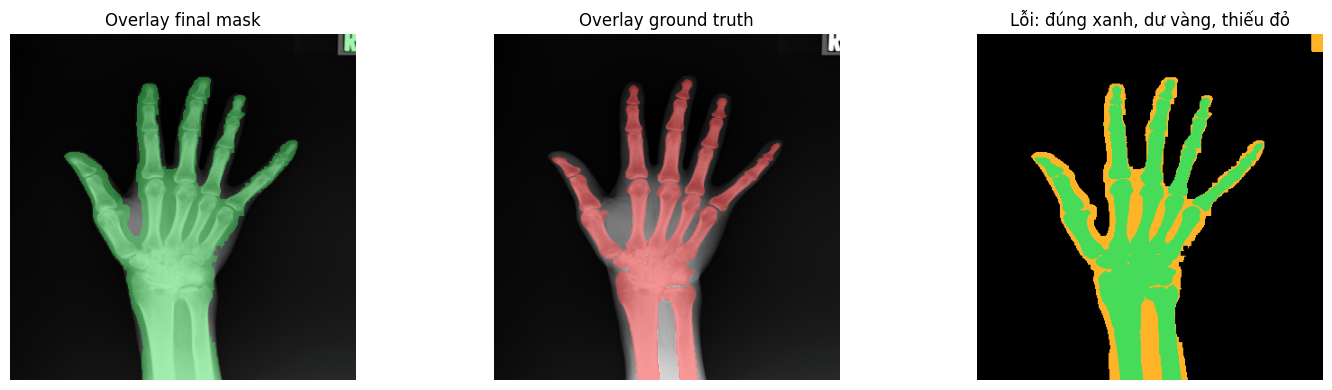

In [44]:
if final_ready:
    final_metrics = binary_metrics_np(final_mask, gt_mask)
    display(pd.DataFrame([{'stage': 'final_mask', **final_metrics}]))

    pred = final_mask.astype(bool)
    gt = gt_mask.astype(bool)
    error_map = np.zeros((*gt.shape, 3), dtype=np.uint8)
    error_map[pred & gt] = [70, 220, 90]
    error_map[pred & ~gt] = [255, 180, 40]
    error_map[~pred & gt] = [255, 40, 40]

    show_row([
        ('Overlay final mask', overlay_mask(input_rgb, pred, color=(60, 230, 90), alpha=0.45), None),
        ('Overlay ground truth', overlay_mask(input_rgb, gt, color=(255, 40, 40), alpha=0.45), None),
        ('Lỗi: đúng xanh, dư vàng, thiếu đỏ', error_map, None),
    ], figsize=(15, 4))
else:
    print('Bỏ qua evaluation vì chưa có final mask.')

## 19. Lưu kết quả của một ảnh

Mục đích: lưu các hình quan trọng của đúng ảnh đang debug, không sinh toàn bộ dataset.

Các file được lưu:

- ảnh đầu vào;
- LayerCAM;
- bone likelihood;
- bone support;
- pseudo mask thô;
- final mask;
- overlay final mask;
- bảng metric.

In [45]:
SAVE_SINGLE_CASE = True

if SAVE_SINGLE_CASE and final_ready:
    case_dir = OUTPUT_ROOT / 'single_case' / Path(image_name).stem
    case_dir.mkdir(parents=True, exist_ok=True)
    Image.fromarray(input_rgb).save(case_dir / '01_anh_dau_vao.png')
    Image.fromarray((fused_cam * 255).astype(np.uint8)).save(case_dir / '02_layercam.png')
    Image.fromarray((bone_likelihood * 255).astype(np.uint8)).save(case_dir / '03_bone_likelihood.png')
    Image.fromarray((bone_support * 255).astype(np.uint8)).save(case_dir / '04_bone_support.png')
    Image.fromarray((raw_pseudo_mask * 255).astype(np.uint8)).save(case_dir / '05_pseudo_mask_tho.png')
    Image.fromarray((final_mask * 255).astype(np.uint8)).save(case_dir / '06_final_mask.png')
    Image.fromarray(overlay_mask(input_rgb, final_mask.astype(bool), color=(60, 230, 90), alpha=0.45)).save(case_dir / '07_overlay_final_mask.png')
    pd.DataFrame([{'stage': 'final_mask', **final_metrics}]).to_csv(case_dir / '08_metrics.csv', index=False, encoding='utf-8-sig')
    print('Đã lưu kết quả tại:', case_dir)
else:
    print('Không lưu vì SAVE_SINGLE_CASE=False hoặc chưa có final mask.')

Đã lưu kết quả tại: /content/drive/MyDrive/Thesis Experiment/debug_outputs/single_case/JP_SARC_P0001_20100423_7383_R


## 20. Chạy pseudo mask cho 1, 5, 10 ảnh hoặc toàn bộ split

Đây là stage tùy chọn. Nó dùng script hiện có của project nhưng không ép bạn sinh toàn bộ dataset.

Tham số của stage này:

- `RUN_BATCH_PSEUDO`: bật/tắt chạy batch.
- `NUM_DEBUG_IMAGES`: số ảnh cần xử lý khi không chạy toàn bộ. Dùng `1`, `5` hoặc `10` để debug nhanh.
- `PROCESS_FULL_SPLIT`: nếu `True`, xử lý toàn bộ split. Chỉ bật khi thật sự cần benchmark.
- `SAVE_VISUALS_LIMIT`: số ảnh đầu tiên được lưu overlay.

Stage sau không phụ thuộc vào việc stage này đã chạy toàn bộ dataset. Nếu chỉ có vài mask, evaluation batch sẽ báo rõ ảnh nào bị thiếu.

In [ ]:
RUN_BATCH_PSEUDO = False
NUM_DEBUG_IMAGES = 5
PROCESS_FULL_SPLIT = False
SAVE_VISUALS_LIMIT = min(NUM_DEBUG_IMAGES, 10)
PSEUDO_BATCH_OUTPUT = OUTPUT_ROOT / 'pseudo_batch'

process_args = ['--process-all'] if PROCESS_FULL_SPLIT else ['--max-images', str(NUM_DEBUG_IMAGES)]
batch_pseudo_cmd = [
    sys.executable, str(PROJECT_DIR / 'generate_pseudo_masks.py'),
    '--ram-root', str(RAM_ROOT),
    '--split', DEBUG_SPLIT,
    '--classifier-checkpoint', str(CLASSIFIER_CHECKPOINT),
    '--sam-checkpoint', str(SAM_CHECKPOINT),
    '--target-columns', ','.join(TARGET_COLUMNS),
    '--image-size', str(IMAGE_SIZE),
    '--batch-size', '1',
    '--num-workers', '0',
    '--confidence-threshold', str(CONFIDENCE_THRESHOLD),
    '--min-component-area', str(COMPONENT_MIN_AREA),
    '--mask-score-threshold', str(MASK_SCORE_THRESHOLD),
    '--selection-method', SELECTION_METHOD,
    '--fusion-topk', str(FUSION_TOPK),
    '--morphology-fusion-mode', 'components',
    '--sam-prompt-mode', SAM_PROMPT_MODE,
    '--max-bone-components', str(MAX_BONE_COMPONENTS),
    '--points-per-component', str(POINTS_PER_COMPONENT),
    '--bbox-padding-ratio', str(BBOX_PADDING_RATIO),
    '--negative-points-per-component', str(NEGATIVE_POINTS_PER_COMPONENT),
    '--bone-seed-percentile', str(BONE_SEED_PERCENTILE),
    '--bone-support-percentile', str(BONE_SUPPORT_PERCENTILE),
    '--closing-kernel', str(CLOSING_KERNEL),
    '--opening-kernel', str(OPENING_KERNEL),
    '--max-hole-area', str(MAX_HOLE_AREA),
    '--min-size', str(MIN_FINAL_SIZE),
    '--save-visuals-limit', str(SAVE_VISUALS_LIMIT),
    *process_args,
    '--output-dir', str(PSEUDO_BATCH_OUTPUT),
]
print('Lệnh batch pseudo mask:')
print(' '.join(batch_pseudo_cmd))

if RUN_BATCH_PSEUDO:
    subprocess.run(batch_pseudo_cmd, check=True)
else:
    print('Không chạy batch vì RUN_BATCH_PSEUDO=False.')

## 21. Xem và đánh giá batch tùy chọn

Mục đích: xem nhanh các mask đã sinh bằng batch và đánh giá những ảnh có mask.

Nếu bạn chỉ sinh 5 ảnh, các ảnh còn lại sẽ được báo `missing`. Đây là hành vi mong muốn cho debug, vì notebook không ép phải sinh toàn bộ dataset.

In [ ]:
RUN_BATCH_EVALUATION = False
BATCH_EVAL_CSV = OUTPUT_ROOT / 'batch_eval.csv'

batch_mask_dir = PSEUDO_BATCH_OUTPUT / 'masks'
batch_overlay_dir = PSEUDO_BATCH_OUTPUT / 'overlays'
batch_masks = sorted(batch_mask_dir.glob('*.png')) if batch_mask_dir.exists() else []
print('Số mask batch hiện có:', len(batch_masks))

if batch_masks:
    val_dir = SEG_ROOT / DEBUG_SPLIT
    n_show = min(5, len(batch_masks))
    fig, axes = plt.subplots(n_show, 3, figsize=(12, 4 * n_show))
    if n_show == 1:
        axes = np.array([axes])
    for row_axes, mask_path in zip(axes, batch_masks[:n_show]):
        stem = mask_path.stem
        image_match = next(iter(sorted(val_dir.glob(f'{stem}.*'))), None)
        overlay_match = next(iter(sorted(batch_overlay_dir.glob(f'{stem}*fused_layercam.png'))), None)
        if image_match is not None:
            row_axes[0].imshow(Image.open(image_match).convert('RGB'))
        row_axes[0].set_title(f'Ảnh gốc\n{stem}')
        if overlay_match is not None:
            row_axes[1].imshow(Image.open(overlay_match).convert('RGB'))
        row_axes[1].set_title('Overlay LayerCAM')
        row_axes[2].imshow(Image.open(mask_path), cmap='gray')
        row_axes[2].set_title('Pseudo mask')
        for ax in row_axes:
            ax.axis('off')
    plt.tight_layout()
    plt.show()

batch_eval_cmd = [
    sys.executable, str(PROJECT_DIR / 'evaluate_ramh1200_masks.py'),
    '--ram-root', str(RAM_ROOT),
    '--split', DEBUG_SPLIT,
    '--pred-mask-root', str(batch_mask_dir),
    '--image-size', str(IMAGE_SIZE),
    '--num-workers', '0',
    '--output-csv', str(BATCH_EVAL_CSV),
]
print('Lệnh đánh giá batch:')
print(' '.join(batch_eval_cmd))

if RUN_BATCH_EVALUATION:
    subprocess.run(batch_eval_cmd, check=True)
else:
    print('Không chạy đánh giá batch vì RUN_BATCH_EVALUATION=False.')

if BATCH_EVAL_CSV.exists():
    batch_eval_df = pd.read_csv(BATCH_EVAL_CSV)
    display(batch_eval_df.tail(15))

## 22. U-Net supervised tùy chọn

Stage này không bắt buộc cho debug weakly supervised pseudo mask. Nó chỉ dùng để có baseline segmentation supervised bằng ground truth RAM-H1200.

Tham số của stage này:

- `RUN_TRAIN_UNET`: chỉ bật khi muốn train baseline.
- `UNET_EPOCHS`: số epoch. Tăng lên có thể tốt hơn nhưng tốn thời gian.
- `UNET_BATCH_SIZE`: tăng nếu GPU đủ VRAM, giảm nếu hết bộ nhớ.

Khi chỉ debug pipeline CAM + morphology + SAM, nên để `RUN_TRAIN_UNET=False`.

In [ ]:
RUN_TRAIN_UNET = False
UNET_EPOCHS = 25
UNET_BATCH_SIZE = 4
UNET_OUTPUT = OUTPUT_ROOT / 'unet_supervised'

unet_cmd = [
    sys.executable, str(PROJECT_DIR / 'train_segmentation.py'),
    '--ram-root', str(RAM_ROOT),
    '--train-split', 'train',
    '--val-split', DEBUG_SPLIT,
    '--image-size', str(IMAGE_SIZE),
    '--batch-size', str(UNET_BATCH_SIZE),
    '--num-workers', '0',
    '--epochs', str(UNET_EPOCHS),
    '--output-dir', str(UNET_OUTPUT),
]
print('Lệnh train U-Net:')
print(' '.join(unet_cmd))

if RUN_TRAIN_UNET:
    subprocess.run(unet_cmd, check=True)
else:
    print('Không train U-Net vì RUN_TRAIN_UNET=False.')

unet_log = UNET_OUTPUT / 'training_log.csv'
if unet_log.exists():
    unet_df = pd.read_csv(unet_log)
    display(unet_df.tail())

## 23. Checklist phân tích sau khi chạy notebook

Sau khi chạy từng stage, hãy tự trả lời:

1. Ảnh sau preprocessing có còn đúng tương phản X-quang không?
2. Classifier có đủ tự tin để LayerCAM đáng tin không?
3. LayerCAM bám vào xương, toàn bàn tay hay nền?
4. Threshold CAM có quá hẹp hoặc quá rộng không?
5. Bone likelihood có làm nổi xương hơn mô mềm không?
6. Seed/support có quá ít, quá rộng, hoặc bị đứt vùng quan trọng không?
7. Component được giữ lại có đúng là vùng xương cần đưa sang SAM không?
8. Prompt point/bbox có nằm đúng trên cấu trúc xương không?
9. SAM candidate tốt bằng mắt có được selection score cao không?
10. Hậu xử lý morphology làm tốt hơn hay làm mất chi tiết xương nhỏ?
11. Dice/IoU thấp là do thiếu xương, dư mô mềm, hay sai ở bước resize/threshold?

Khi cần cải thiện, ưu tiên chỉnh theo thứ tự:

1. `CAM_PERCENTILE`;
2. `BONE_SEED_PERCENTILE` và `BONE_SUPPORT_PERCENTILE`;
3. `COMPONENT_MIN_AREA` và `MAX_BONE_COMPONENTS`;
4. `SAM_PROMPT_MODE`;
5. `MASK_SCORE_THRESHOLD` và `FUSION_TOPK`;
6. `CLOSING_KERNEL`, `OPENING_KERNEL`, `MIN_FINAL_SIZE`.